<a href="https://colab.research.google.com/github/AbdulmoizRashid/Data-Analysis-Project/blob/main/Cafe_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/sample_data/dirty_cafe_sales.csv')

In [3]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
df['Transaction ID'].duplicated().sum()

np.int64(0)

In [6]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [7]:
df['Item'].value_counts()

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344


In [8]:
df.dropna(subset='Item',inplace=True)

In [9]:
df['Item'].isnull().sum()

np.int64(0)

In [10]:
df=df[~df['Item'].isin(['UNKNOWN','ERROR'])]

In [11]:
df['Item'].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'Sandwich',
       'Juice', 'Tea'], dtype=object)

In [12]:
df['Item'].value_counts()

,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089


In [13]:
df.shape

(9031, 8)

In [14]:
df=df[~(df['Quantity'].isna() & df['Price Per Unit'].isna())]

In [15]:
df.shape

(9030, 8)

In [16]:
df['Quantity'].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [17]:
df['Quantity']=pd.to_numeric(df['Quantity'],errors='coerce')

In [18]:
df['Quantity'].unique()

array([ 2.,  4.,  5.,  3.,  1., nan])

In [19]:
df['Quantity'].isna().sum()

np.int64(419)

In [20]:
df['Quantity'].fillna(df['Quantity'].median(),inplace=True)

/tmp/ipykernel_13411/549334851.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].median(),inplace=True)


In [21]:
df['Quantity'].isna().sum()

np.int64(0)

In [22]:
df['Price Per Unit']=pd.to_numeric(df['Price Per Unit'],errors='coerce')

In [23]:
df['Price Per Unit'].value_counts()

,count
Price Per Unit,
3.0,2195
4.0,2118
2.0,1108
5.0,1082
1.0,1026
1.5,1023


In [24]:
df['Price Per Unit'].isna().sum()

np.int64(478)

In [25]:
df['Price Per Unit']=df.groupby('Item')['Price Per Unit'].transform(lambda x: x.fillna(x.median()))

In [26]:
df['Price Per Unit'].isna().sum()

np.int64(0)

In [27]:
df['Total Spent']=df['Quantity']*df['Price Per Unit']

In [28]:
df['Total Spent'].isna().sum()

np.int64(0)

In [29]:
df['Total Spent'].describe()

,Total Spent
count,9030.000000
mean,8.940144
std,5.926932
min,1.000000
25%,4.000000
50%,8.000000
75%,12.000000
max,25.000000


In [30]:
df['Payment Method'].unique()

array(['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', nan, 'ERROR'],
      dtype=object)

In [31]:
df['Payment Method'].value_counts()

,count
Payment Method,
Digital Wallet,2065
Cash,2046
Credit Card,2043
ERROR,285
UNKNOWN,261


In [32]:
df['Payment Method'].isna().sum()

np.int64(2330)

In [33]:
df['Payment Method'].fillna('UNKNOWN',inplace=True)

/tmp/ipykernel_13411/4084514019.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('UNKNOWN',inplace=True)


In [34]:
df['Payment Method'].isna().sum()

np.int64(0)

In [35]:
df['Location'].unique()

array(['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR'], dtype=object)

In [36]:
df['Location'].fillna('Not Provided',inplace=True)

/tmp/ipykernel_13411/1553625232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Location'].fillna('Not Provided',inplace=True)


In [37]:
df['Transaction Date']=pd.to_datetime(df['Transaction Date'],errors='coerce')

In [38]:
df['Transaction Date'].isna().sum()

np.int64(418)

In [39]:
df.dropna(subset='Transaction Date',inplace=True)

In [44]:
df.rename(columns={'Location':'Order Type'},inplace=True)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8612 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    8612 non-null   object        
 1   Item              8612 non-null   object        
 2   Quantity          8612 non-null   float64       
 3   Price Per Unit    8612 non-null   float64       
 4   Total Spent       8612 non-null   float64       
 5   Payment Method    8612 non-null   object        
 6   Order Type        8612 non-null   object        
 7   Transaction Date  8612 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 605.5+ KB


In [46]:
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,8612.000000,8612.000000,8612.000000,8612
mean,3.025662,2.951986,8.937703,2023-07-02 04:24:31.435206912
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-03 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.388161,1.278349,5.924621,NaN


In [47]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Order Type,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


# **Most Selling Item**
 Which item generates the most revenue and which generates the least and what should the cafe do about the least performing item?

In [101]:
Most_sell=df.groupby('Item')['Total Spent'].sum().reset_index()

In [102]:
Most_sell=pd.DataFrame(Most_sell)

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Cake'),
  Text(1, 0, 'Coffee'),
  Text(2, 0, 'Cookie'),
  Text(3, 0, 'Juice'),
  Text(4, 0, 'Salad'),
  Text(5, 0, 'Sandwich'),
  Text(6, 0, 'Smoothie'),
  Text(7, 0, 'Tea')])

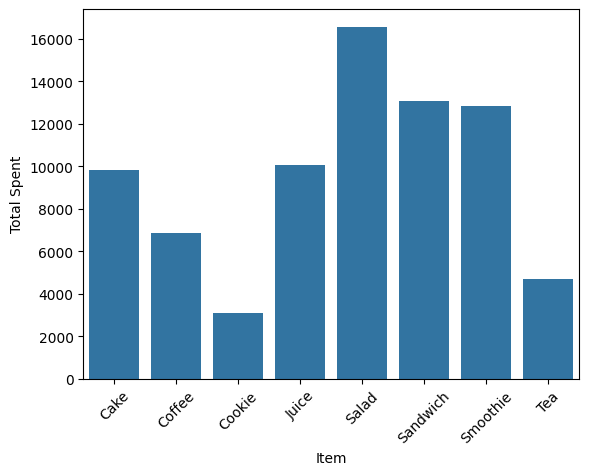

In [104]:
sns.barplot(x='Item',y='Total Spent',data=Most_sell)
plt.xticks(rotation=45)


**Top Performer:** Salads (indicates high demand for healthy, savory choices).

**Secondary Success:** Refreshment drinks are maintaining strong momentum.

**Primary Challenge:** Cookies are the least-sold item, suggesting our "Specialty Sweets" are missing the mark.

**Recommendation**: Prioritize a quality and aesthetic overhaul of the dessert menu. Since these are our signature products, improving their taste and "Instagram-worthy" presentation is essential for brand growth.

# **Month Sales Analysis**
Which month has the highest and lowest sales is there a seasonal pattern and what does that mean for inventory or staffing?

In [85]:
df['Months']=df['Transaction Date'].dt.month_name().sort_values()


In [99]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales=df.groupby('Months')['Total Spent'].sum().reset_index()
monthly_sales=pd.DataFrame(monthly_sales)
monthly_sales.reset_index(drop=True,inplace=True)
monthly_sales['Months']=pd.Categorical(monthly_sales['Months'],categories=month_order,ordered=True)
monthly_sales.sort_values('Months',inplace=True)
monthly_sales

,Months,Total Spent
4,January,6712.0
3,February,5926.5
7,March,6556.0
0,April,6490.5
8,May,6254.5
6,June,6639.0
5,July,6204.5
1,August,6309.0
11,September,6223.0
10,October,6739.5


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'January'),
  Text(1, 0, 'February'),
  Text(2, 0, 'March'),
  Text(3, 0, 'April'),
  Text(4, 0, 'May'),
  Text(5, 0, 'June'),
  Text(6, 0, 'July'),
  Text(7, 0, 'August'),
  Text(8, 0, 'September'),
  Text(9, 0, 'October'),
  Text(10, 0, 'November'),
  Text(11, 0, 'December')])

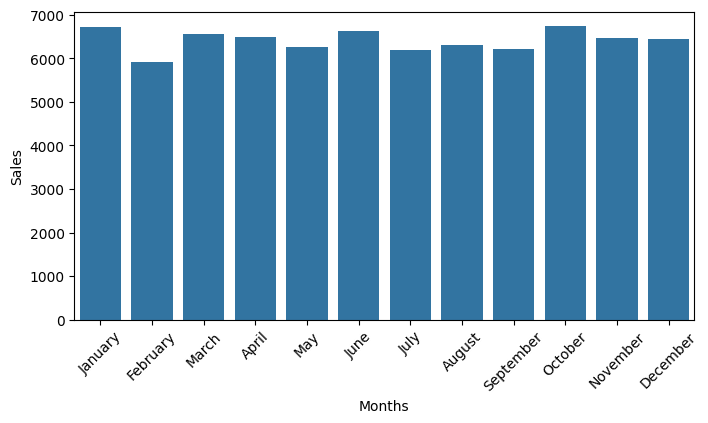

In [100]:
plt.figure(figsize=(8,4))
sns.barplot(x='Months',y='Total Spent',data=monthly_sales)
plt.xlabel('Months')
plt.ylabel('Sales')
plt.xticks(rotation=45)

Analysis of monthly sales reveals a uniform performance trend with no significant seasonal fluctuations. This consistency indicates that our inventory management and staffing levels are currently optimized for steady demand. Maintaining this "flat" sales curve suggests a reliable, year-round customer base, allowing for predictable overhead costs and efficient resource allocation.

# **Payment Methods**
Which payment method is most popular should the cafe prioritize any particular payment infrastructure?

<Axes: xlabel='Payment Method', ylabel='Count'>

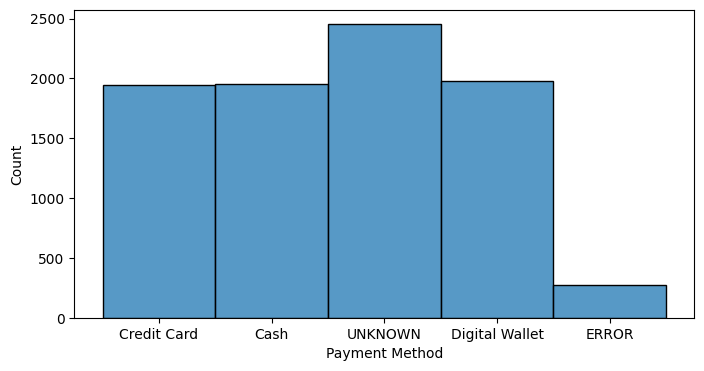

In [87]:
plt.figure(figsize=(8,4))
sns.histplot(data=df,x='Payment Method')


Preliminary analysis suggests that payment method data is currently under-reported or improperly logged. The existing data shows an identical distribution across all payment types with zero consumer preference—a statistical anomaly that likely indicates a systemic recording error rather than actual user behavior.

While our operational performance (inventory and staffing) remains stable and uniform, we recommend a technical audit of the Point of Sale (POS) system to ensure payment preferences are being captured accurately. Correcting this will allow for a more nuanced understanding of our customer's transaction habits.

# **Order Gateway**
Which order type takeaway or in store generates more revenue and what does that mean for the cafe's space and service strategy?

In [88]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Order Type,Transaction Date,Months
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,September
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,May
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,July
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27,April
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,June


<Axes: xlabel='Order Type', ylabel='Count'>

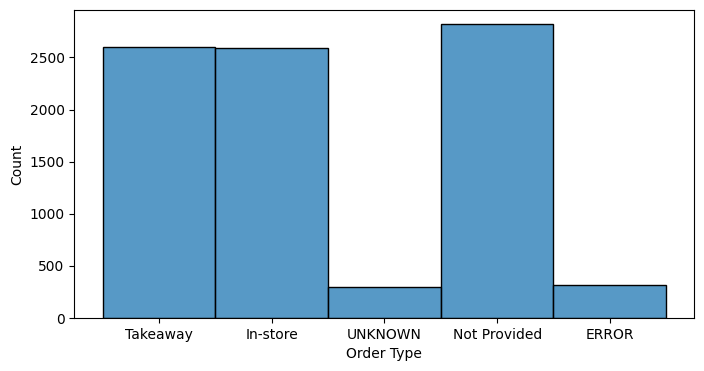

In [89]:
plt.figure(figsize=(8,4))
sns.histplot(data=df,x='Order Type')

Similar to the payment data, the Order Type metrics appear to be improperly logged. The current data reflects an exact 50/50 split between methods, which is a statistical improbability that fails to reveal true consumer habits. This lack of data granularity prevents us from understanding whether the cafe is primarily a "Dine-in" or "Grab-and-go" establishment. Strengthening our data entry protocols for order types is essential to making informed decisions about floor space and packaging needs.

# **Average Transaction per Item**
What is the average transaction value per item which items have customers spending the most per visit?

In [90]:
avg_item_tran=df.groupby('Item')['Total Spent'].mean().reset_index()

In [94]:
avg_item_tran=pd.DataFrame(avg_item_tran)
avg_item_tran

,Item,Total Spent
0,Cake,9.088725
1,Coffee,6.099733
2,Cookie,2.988406
3,Juice,8.943950
4,Salad,15.077343
5,Sandwich,12.152700
6,Smoothie,12.244275
7,Tea,4.564265


<Axes: xlabel='Item', ylabel='Total Spent'>

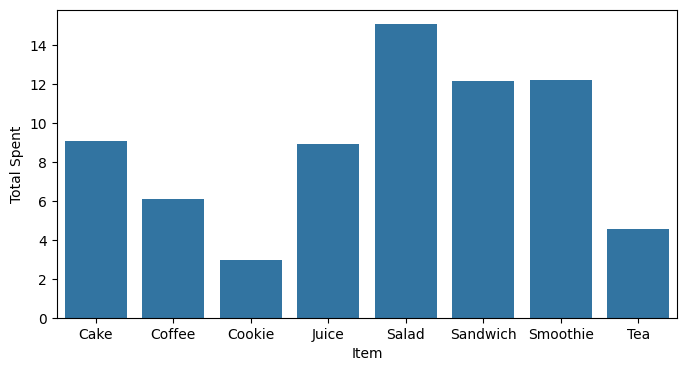

In [95]:
plt.figure(figsize=(8,4))
sns.barplot(x='Item',y='Total Spent',data=avg_item_tran)

Current transaction data reveals a high consumer spend on Healthy and Savory items, with Salads commanding an average transaction of $14 and Sandwiches averaging $12. Furthermore, Fresh Drinks show exceptional performance, with transaction values ranging from $8 to $21.

Strategic Recommendation: We should increase our marketing efforts for these high-value categories to capitalize on existing momentum. Simultaneously, we must address the performance gap in our Core Cafe Specialties (Cakes, Coffee, and Cookies). As these items are traditionally the primary "draw" for cafe patrons, a focused effort on recipe refinement and targeted marketing is essential to re-establish them as the main drivers of foot traffic and brand identity

# **Strategic Business Recommendation Report**
# 1. **Operational Performance: "Stability & Efficiency"**
The Insight: Monthly sales are uniform and consistent, showing no seasonal volatility.

**The Verdict**: Current inventory management and staffing levels are highly optimized. The business is running at peak operational efficiency with a reliable, year-round customer base.

**Recommendation**: Maintain current resource allocation models, as they are successfully supporting steady demand without wasted overhead.

# **2. Revenue Drivers: "Savory & Refreshment Growth"**
**The Insight**: Customers are showing a high "willingness to spend" on fresh, healthy options. Salads (14 dollars average) and Sandwiches (12 dollars average) are the primary revenue anchors. Fresh Drinks are exceptionally strong, commanding transactions between 8 dollars and 12 dollars.

**Recommendation:** Shift marketing focus to highlight these high-value "Savory & Fresh" items. Consider "Bundle Deals" (e.g., Salad + Fresh Drink) to further increase the Average Transaction Value (ATV).

# **3. Brand Growth: "Signature Specialty Audit"**
**The Insight:** Despite being the "heart" of the cafe, Specialty Sweets (Cakes, Cookies) and Coffee are underperforming and are currently the least-sold items.

**The Verdict:** Since these items are the primary "draw" for cafe patrons, their low performance suggests a disconnect in quality or appeal.

**Recommendation:** Conduct an immediate recipe and visual presentation audit. Refresh the aesthetic of the dessert case and re-market these signature items to re-establish the cafe’s identity as a premier destination for sweets and coffee.

# **4. Data Integrity: "Systemic Reporting Correction"**
**The Insight:** Data for Payment Methods and Order Types (Dine-in vs. Takeaway) currently shows an improbable "equal" distribution across all categories.

**The Verdict**: This is a statistical anomaly indicating that data is not being entered correctly at the Point of Sale (POS). It currently offers no "true revelation" of customer habits.

**Recommendation:** Perform a POS system audit and staff training session to ensure transaction details are captured accurately. Accurate data is essential for making future decisions regarding packaging costs and floor space.

# **Executive Summary:**
The cafe is operationally healthy and has found a lucrative niche in healthy savory items. To reach the next level of growth, the business must fix its data reporting "blind spots" and revitalize its signature sweet specialties to match the high performance of its salad and drink lines.